In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [245]:
pwd

'C:\\Users\\Shrijan Aryal\\Titanic'

In [246]:
ls

 Volume in drive C is Windows
 Volume Serial Number is E8A9-D000

 Directory of C:\Users\Shrijan Aryal\Titanic

04/03/2025  08:52 PM    <DIR>          .
04/03/2025  08:52 PM    <DIR>          ..
03/30/2025  12:04 AM    <DIR>          .ipynb_checkpoints
03/29/2025  04:51 PM            33,673 best_model.pkl
04/03/2025  08:14 PM            42,939 best_model2.pkl
04/03/2025  08:51 PM             3,258 submissionApril.csv
04/03/2025  08:52 PM             1,008 submissionApril.zip
03/30/2025  09:40 PM             3,258 submissionI.csv
03/30/2025  09:41 PM             1,000 submissionI.zip
03/24/2025  02:23 PM            28,629 test.csv
04/03/2025  08:15 PM           829,726 Titanic.ipynb
04/03/2025  08:52 PM           113,174 Titanic_prediction.ipynb
03/30/2025  12:03 AM            31,102 titanic_predictions.csv
04/03/2025  08:50 PM            31,948 titanic_predictions2.csv
03/26/2025  06:49 PM            61,194 Titanic_train.csv
              12 File(s)      1,180,909 bytes
               

In [247]:
data = pd.read_csv('Titanic_train.csv')

In [248]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [249]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [250]:
for item in data.columns:
    print(f'Total missing vlaues for {item}: {data[item].isnull().sum()}')

Total missing vlaues for PassengerId: 0
Total missing vlaues for Survived: 0
Total missing vlaues for Pclass: 0
Total missing vlaues for Name: 0
Total missing vlaues for Sex: 0
Total missing vlaues for Age: 177
Total missing vlaues for SibSp: 0
Total missing vlaues for Parch: 0
Total missing vlaues for Ticket: 0
Total missing vlaues for Fare: 0
Total missing vlaues for Cabin: 687
Total missing vlaues for Embarked: 2


In [251]:
# So, from the above observation, we can see that 'age' and 'cabin' have the most missing values and 'Embarked' with 2 of them
# 'Age' refers to the age of the traveller and 'Cabin' is the cabin number. 'Embarked' is the port of Embarkation

In [252]:
data['Age'].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

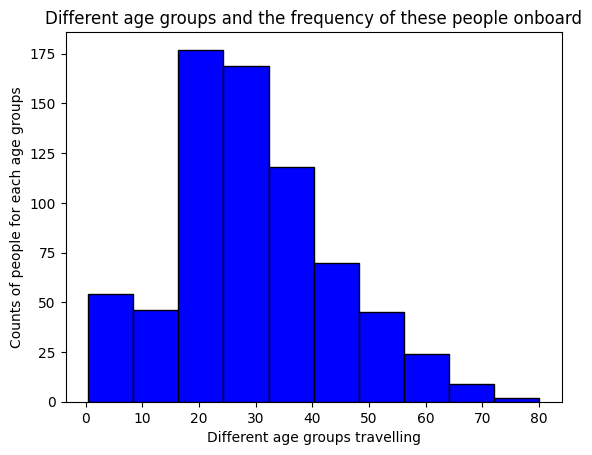

In [253]:
plt.hist(data['Age'], bins=10, color='blue', edgecolor='black')
plt.xlabel("Different age groups travelling")
plt.ylabel("Counts of people for each age groups")
plt.title("Different age groups and the frequency of these people onboard")
plt.show()

In [178]:
# The graph shows that the data is not normally distributed. So, we cannot use mean to replace the missing age values


In [254]:
print(f'The mean of age is {data['Age'].mean()}, the median is {data['Age'].median()}, and the standard deviation is {data['Age'].std()} ')

The mean of age is 29.69911764705882, the median is 28.0, and the standard deviation is 14.526497332334042 


In [255]:
# We know, skewness = 3(mean-median)/ standard deviation
skewness = (3*(data['Age'].mean()-data['Age'].median()))/(data['Age'].std())
print(f'The skewness of the data for the age is: {skewness}')

The skewness of the data for the age is: 0.3509003460751983


In [256]:
# And since the data is fairly skewed towards the left, we can clearly say that the younger age group we more onboard than
# the older ones as can be seen on the grpah above as well.


In [257]:
data.columns
# Looking at the columns, we can discard few of the attributes that might have no relations with the age
# Few of these could be:
#'Embarked' - Embarkation port may not be really important

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

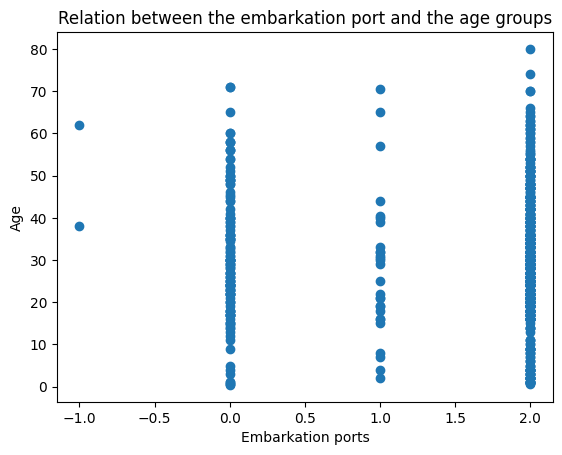

In [258]:
cabin = data['Embarked']
if cabin.dtype == 'object':
    cabin = cabin.astype('category').cat.codes
plt.scatter(cabin,data['Age'])
plt.xlabel('Embarkation ports')
plt.ylabel('Age')
plt.title("Relation between the embarkation port and the age groups")
plt.show()

In [259]:
# Well, it can be seen that the embarkation port does not show noticeable linear relation with the age.
# Let's now, try to what columns does age have relation with. For reference point, we can always look back to the graph above
# So, we will use the pearsonr from scipy to see the relations. It works only when there are no missing values
# There are missing values in 'Embarked' which we will deal first
# Then, we will exclude the 'Cabin' column while proceding with the procedure


In [260]:
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
print(f'The total missing values for the Embarked is {data['Embarked'].isnull().sum()}')

The total missing values for the Embarked is 0


In [261]:
temp = data

[0.036847197861327834, -0.07722109457217767, -0.36922601531551735, 0.06554416099839347, 0.09325357685567744, -0.3082467589236564, -0.18911926263203527, -0.0818200744116728, 0.09606669176903891, -0.030394332235829755]


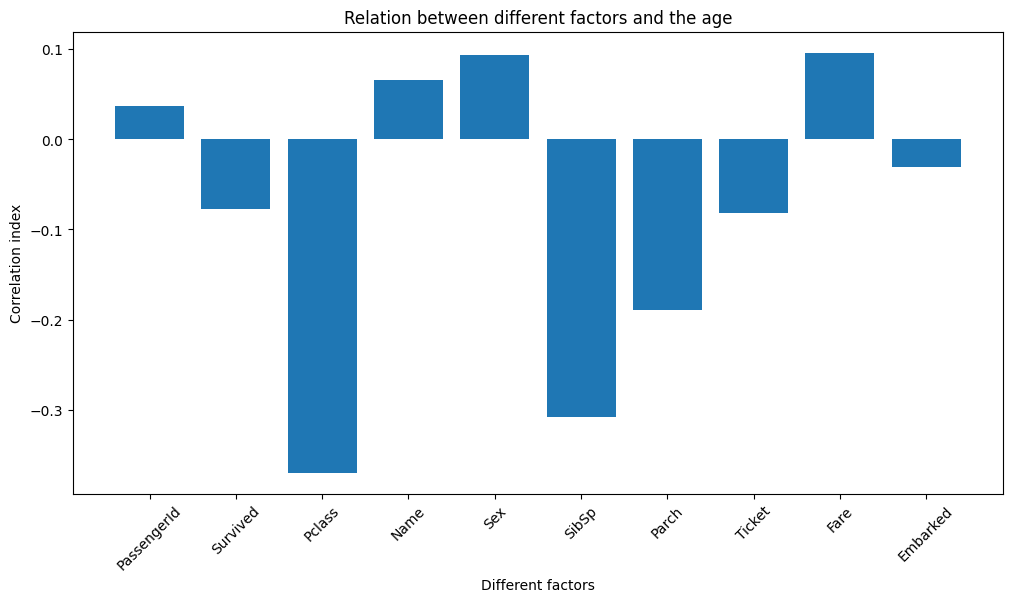

In [262]:
data_temp = temp.dropna(subset=['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Age'])

y = data_temp["Age"]
# Since the pearsonr requires no missing values, we will clean the data in y such that it has no missing values
  

from scipy.stats import pearsonr
cols = ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked']

cols_score = []

for col in cols:
    x = data_temp[col]
    if x.dtype == 'object':
        x = x.astype('category').cat.codes
    correlation = pearsonr(x,y)
    cols_score.append(correlation.statistic)
    
print(cols_score)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(cols,cols_score)
plt.title("Relation between different factors and the age")
plt.xlabel("Different factors")
plt.ylabel("Correlation index")
plt.xticks(rotation = 45)
plt.show()

In [263]:
# This graph shows that there is a relation between age and different factors like Pclass, SibSp, Parch
# So, we can check these factors out and see what kinds of relation there is 

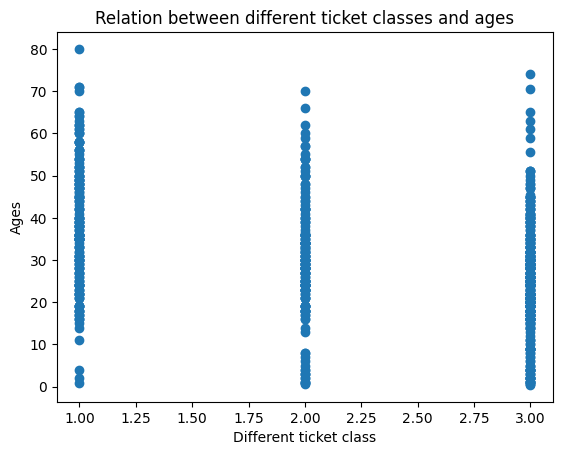

In [264]:
plt.scatter(data['Pclass'], data['Age'])
plt.xlabel("Different ticket class")
plt.ylabel("Ages")
plt.title("Relation between different ticket classes and ages")
plt.show()

In [265]:
# So, this shows that there is a relation between the ages and the classes. 
# It shows that less number of people are at the higher class
# However, this is also due to the population
# The people of higher age group is less, so it is likely to see the result

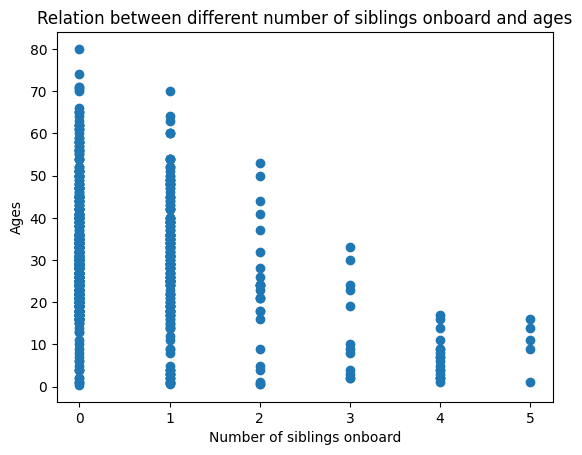

In [266]:
plt.scatter(data['SibSp'], data['Age'])
plt.xlabel("Number of siblings onboard")
plt.ylabel("Ages")
plt.title("Relation between different number of siblings onboard and ages")
plt.show()

In [267]:
# This also shows a clear relation that the higher age groups less likely had siblings onboard

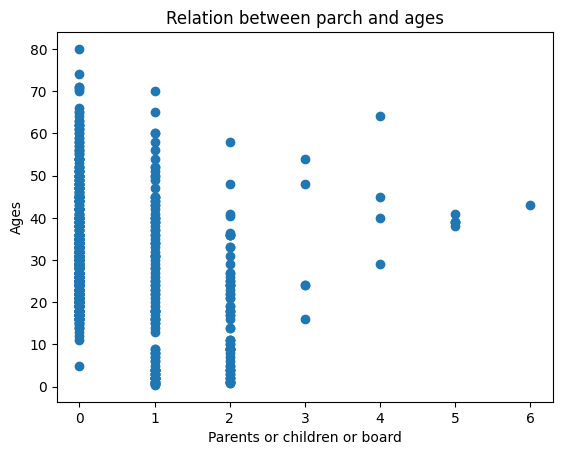

In [268]:
plt.scatter(data['Parch'], data['Age'])
plt.xlabel("Parents or children or board")
plt.ylabel("Ages")
plt.title("Relation between parch and ages")
plt.show()

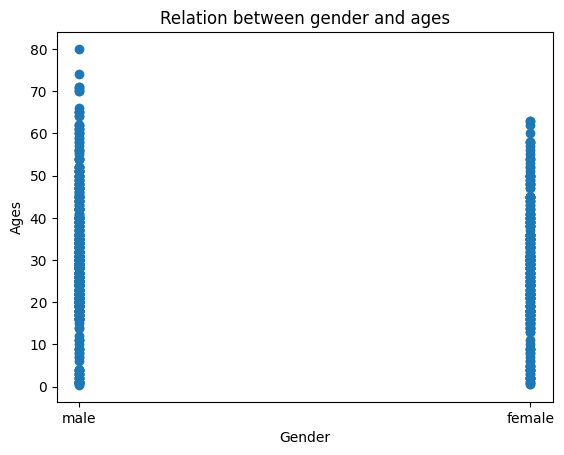

In [269]:
plt.scatter(data['Sex'], data['Age'])
plt.xlabel("Gender")
plt.ylabel("Ages")
plt.title("Relation between gender and ages")
plt.show()

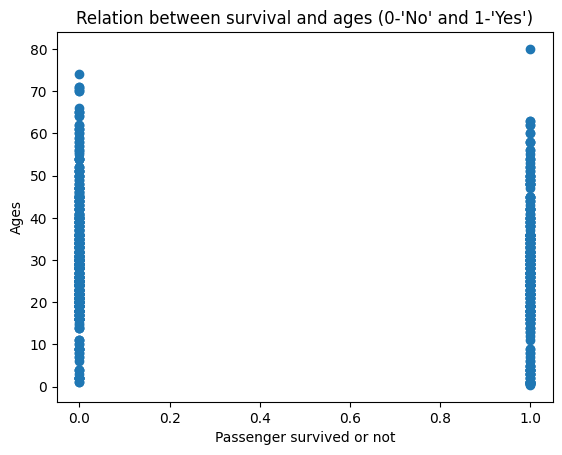

In [270]:
plt.scatter(data['Survived'], data['Age'])
plt.xlabel("Passenger survived or not")
plt.ylabel("Ages")
plt.title("Relation between survival and ages (0-'No' and 1-'Yes')")
plt.show()

In [271]:
# Since most of the factors that we have looked at here shows a linear relation, we can consider using linear regression
# Survival and gender show some specific trend; however, these can also be interpreted as the ones showing linear realtion with age.
# The survival can be viewed linearly such as: if the passenger has not survived, he/she could be of the higher age
# Regarding the gender, if the passenger is a male then he could likely be of the age higher than 65, if female then not

In [272]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [273]:
data['Family'] = 1 + data['SibSp'] + data['Parch']

In [274]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [275]:
import pandas as pd

data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.')

# Check unique titles
print(data['Title'].value_counts())


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


In [276]:
# Define title mapping
title_mapping = {
    "Mr": "Mr", 
    "Miss": "Miss", 
    "Mrs": "Mrs", 
    "Master": "Master",
    "Dr": "Rare", "Rev": "Rare", "Mlle": "Miss", "Major": "Rare",
    "Col": "Rare", "Countess": "Rare", "Capt": "Rare", 
    "Ms": "Miss", "Sir": "Rare", "Lady": "Rare", 
    "Mme": "Mrs", "Don": "Rare", "Jonkheer": "Rare"
}

# Apply mapping
data['Title'] = data['Title'].map(title_mapping)

# Check the updated title distribution
print(data['Title'].value_counts())


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [277]:
import pandas as pd
data = pd.get_dummies(data, columns=['Title'], drop_first=True)


In [278]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare'],
      dtype='object')

In [279]:
# Convert boolean values to 0 and 1
title_columns = ['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
data[title_columns] = data[title_columns].astype(int)

# Check if conversion was successful
print(data[title_columns].dtypes)
print(data.head())


Title_Miss    int32
Title_Mr      int32
Title_Mrs     int32
Title_Rare    int32
dtype: object
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  Family  Title_Miss  \
0      0         A/5 21171   7.2500   NaN        S       2           0   
1      0          PC 17599  71.2833   C85        C       2           0   
2   

In [280]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0,1,0,0


In [281]:
data['IsElderly'] = (data['Age'] >= 60).astype(int)


In [282]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly'],
      dtype='object')

In [283]:
# One-hot encode the 'Sex' column
data = pd.get_dummies(data, columns=['Sex'], drop_first=True)

print(data.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly', 'Sex_male'],
      dtype='object')


In [284]:
data['Pclass_Sex'] = data['Pclass'] * data['Sex_male']


In [285]:
data.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,IsElderly,Sex_male,Pclass_Sex
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,1,0,0,0,True,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,2,0,0,1,0,0,False,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0,0,0,0,False,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,2,0,0,1,0,0,False,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1,0,1,0,0,0,True,3


In [286]:
col = ['Pclass','Family','Survived','Sex_male','Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly','Fare','Pclass_Sex']
data_missing = data[data['Age'].isnull()][col]
data_complete = data[data['Age'].notnull()][col]

In [58]:
# for col in data_complete['Sex']:
#     if col == 'female':
#         col = 0
#     else:
#         col = 1

In [287]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

In [288]:
data.head(15)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,IsElderly,Sex_male,Pclass_Sex
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,1,0,0,0,True,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,2,0,0,1,0,0,False,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,0,0,0,0,False,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,2,0,0,1,0,0,False,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1,0,1,0,0,0,True,3
5,6,0,3,"Moran, Mr. James",NaN,0,0,330877,8.4583,NaN,Q,1,0,1,0,0,0,True,3
6,7,0,1,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,S,1,0,1,0,0,0,True,1
7,8,0,3,"Palsson, Master. Gosta Leonard",2.0,3,1,349909,21.0750,NaN,S,5,0,0,0,0,0,True,3
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,347742,11.1333,NaN,S,3,0,0,1,0,0,False,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,237736,30.0708,NaN,C,2,0,0,1,0,0,False,0


In [289]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# Assume data_complete is already defined and contains the necessary columns
# col contains feature column names, and 'Age' is the target variable.
X_complete = data_complete[col]  # Features
y_complete = data[data['Age'].notnull()]['Age']  # Target variable

# Define models and their hyperparameter grids
models = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {}  # No hyperparameters to tune for the basic model.
    },
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [None, 3, 5, 7, 10],
            'min_samples_split': [2, 5, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 3, 5, 7],
            'min_samples_split': [2, 5, 10]
        }
    },
    'GBM': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    }
}

# List to collect the results
results = []

# Iterate through each model and perform grid search with 5-fold CV
for name, config in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(config['model'],
                        config['params'],
                        cv=5,
                        scoring='neg_mean_squared_error',  # negative MSE for regression
                        n_jobs=-1)
    grid.fit(X_complete, y_complete)
    
    # Calculate RMSE from the best negative MSE score
    best_rmse = np.sqrt(-grid.best_score_)
    
    results.append({
        'Model': name,
        'Best_RMSE': best_rmse,
        'Best_Params': grid.best_params_
    })

# Convert results to a DataFrame and print
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)


Tuning LinearRegression...
Tuning DecisionTree...
Tuning RandomForest...
Tuning GBM...
Tuning KNN...

Hyperparameter Tuning Results:
              Model  Best_RMSE  \
0  LinearRegression   9.813188   
1      DecisionTree  10.676692   
2      RandomForest   9.855797   
3               GBM   9.877865   
4               KNN  12.882071   

                                         Best_Params  
0                                                 {}  
1          {'max_depth': 5, 'min_samples_split': 10}  
2  {'max_depth': 7, 'min_samples_split': 10, 'n_e...  
3  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  
4          {'n_neighbors': 9, 'weights': 'distance'}  


In [214]:
data_complete.columns

Index(['Pclass', 'Family', 'Survived', 'Sex_male', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'IsElderly', 'Fare', 'Pclass_Sex'],
      dtype='object')

In [290]:
col = ['Pclass','Family','Survived','Sex_male','Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly','Fare','Pclass_Sex']
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold


# Separate data with known and unknown ages from the original dataset
X_known = data_complete.loc[data['Age'].notnull(), col]
y_known = data.loc[data['Age'].notnull(), 'Age']
X_unknown = data.loc[data['Age'].isnull(), col]

# Define the RandomForestRegressor with grid search
rf_model = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

# Perform GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_model, 
    param_grid=param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # negative MSE for regression
    n_jobs=-1  # Use all available cores
)

# Fit the grid search
grid_search.fit(X_known, y_known)

# Best model details
print("Best Parameters:", grid_search.best_params_)

# Calculate RMSE from the best negative MSE score
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Best RMSE: {best_rmse}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Perform 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_rf_model, 
    X_known, 
    y_known, 
    cv=cv, 
    scoring='neg_mean_squared_error'
)

# Convert to RMSE
cv_rmse_scores = np.sqrt(-cv_scores)

# Print cross-validation results
print("\nCross-Validation Results:")
print("RMSE scores:", cv_rmse_scores)
print("Mean RMSE: {:.4f} (+/- {:.4f})".format(
    cv_rmse_scores.mean(), 
    cv_rmse_scores.std() * 2
))

# Predict missing ages
predicted_ages = best_rf_model.predict(X_unknown)

# Create a copy of the original dataframe
data_imputed = data.copy()

# Fill missing ages with predictions
data_imputed.loc[data_imputed['Age'].isnull(), 'Age'] = predicted_ages

# Validation
print("\nMissing Age Values:")
print("Before imputation:", data['Age'].isnull().sum())
print("After imputation:", data_imputed['Age'].isnull().sum())

data['Age'] = data_imputed['Age']

Best Parameters: {'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 200}
Best RMSE: 9.855797407500082

Cross-Validation Results:
RMSE scores: [ 9.53571068 10.32212433  9.28786801  9.21441797 10.57255167]
Mean RMSE: 9.7865 (+/- 1.1112)

Missing Age Values:
Before imputation: 177
After imputation: 0


In [ ]:
# While dealing with the missing vlaues for the cabin, we will firstly,
# plot the relation between age and cabin
# If there is no relation at all, we can exclude age column entirely while predicting cabin
# And if there is some relation, we might have to come up with the filled age coulumn

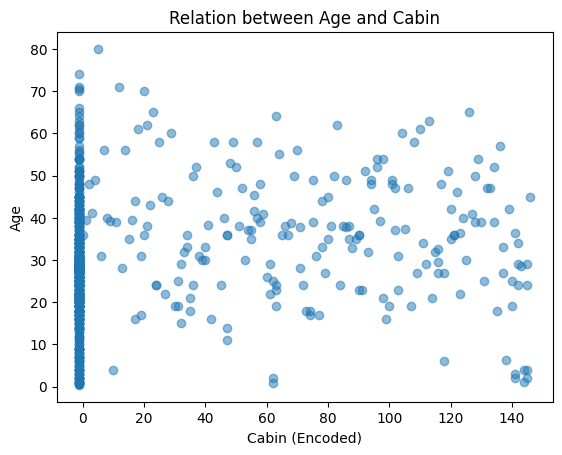

In [291]:
# Let's see if there is a relation between age and the cabin column
# While we do some kind of model selection to fill out missing values for cabin, we want to know if we have to deal with
# the age column or not. That is trying to observe if they have any relations


    
import matplotlib.pyplot as plt
import pandas as pd

cdata = data
# Convert 'Cabin' into categorical codes
cdata['Cabin_Code'] = cdata['Cabin'].astype('category').cat.codes  # Assigns a unique number to each unique Cabin

# Scatter plot using the numerical Cabin_Code
plt.scatter(cdata['Cabin_Code'], cdata['Age'], alpha=0.5)
plt.xlabel('Cabin (Encoded)')
plt.ylabel('Age')
plt.title('Relation between Age and Cabin')
plt.show()

In [292]:
data['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [ ]:
# We are yet to use these ages. We will use them while doing predictive modelling to deal with the missing values in cabin
# X_missing = data[data['Age'].isnull()][col]
# best_params = results_df[results_df['Model'] == 'RandomForest']['Best_Params'].values[0]
# rf_model = RandomForestRegressor(**best_params, random_state=42)
# rf_model.fit(X_complete, y_complete)
# predicted_ages = rf_model.predict(X_missing)
# data.loc[data['Age'].isnull(), 'Age'] = predicted_ages


In [ ]:
# Now, we will try to visualize few things by extracting important information from the cabin column

In [293]:
import pandas as pd
import numpy as np
import re

# Function to extract the deck letter
def extract_deck(cabin):
    if pd.isna(cabin):
        return np.nan
    # If there are multiple cabins listed (e.g., "C23 C25"), take the first one.
    cabin = cabin.split()[0]
    return cabin[0]

# Function to extract the cabin number
def extract_cabin_number(cabin):
    if pd.isna(cabin):
        return np.nan
    cabin = cabin.split()[0]
    match = re.search(r'(\d+)', cabin)
    if match:
        return int(match.group(1))
    return np.nan

# Apply the functions to create new features
data['Deck'] = data['Cabin'].apply(extract_deck)
data['Cabin_Number'] = data['Cabin'].apply(extract_cabin_number)


In [294]:
def cabin_position(num):
    if pd.isna(num):
        return np.nan
    # You can adjust the threshold if needed
    return 'bow' if num < 50 else 'back'

data['Cabin_Position'] = data['Cabin_Number'].apply(cabin_position)


In [295]:
# Survival rates by deck
survival_by_deck = data.groupby('Deck')['Survived'].mean()
print(survival_by_deck)

# Survival rates by cabin position (bow/back)
survival_by_position = data.groupby('Cabin_Position')['Survived'].mean()
print(survival_by_position)


Deck
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
T    0.000000
Name: Survived, dtype: float64
Cabin_Position
back    0.654321
bow     0.695652
Name: Survived, dtype: float64


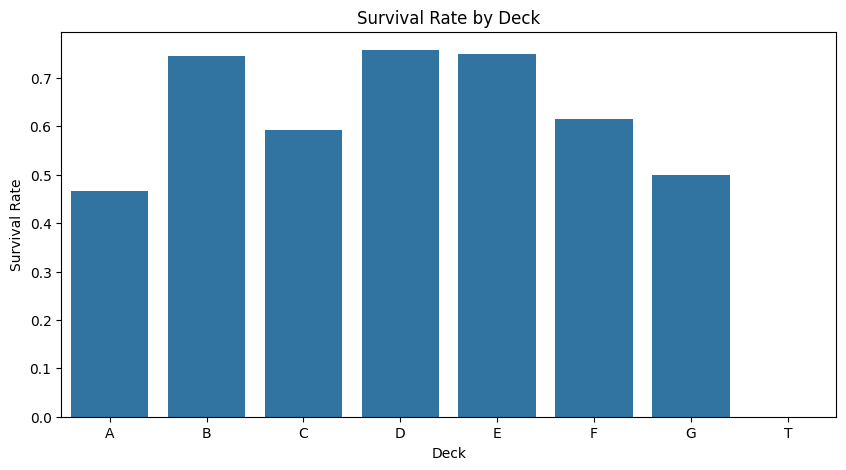

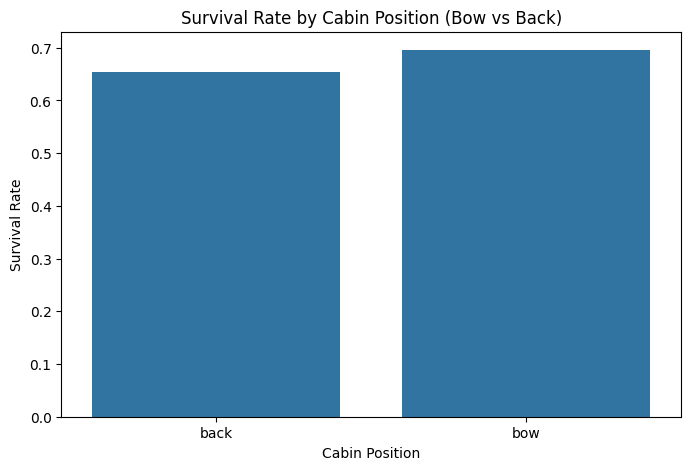

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot survival rate by deck
plt.figure(figsize=(10, 5))
sns.barplot(x=survival_by_deck.index, y=survival_by_deck.values)
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Deck')
plt.show()

# Plot survival rate by cabin position (bow/back)
plt.figure(figsize=(8, 5))
sns.barplot(x=survival_by_position.index, y=survival_by_position.values)
plt.xlabel('Cabin Position')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Cabin Position (Bow vs Back)')
plt.show()


In [297]:
# There is not much difference seen in the survival thing based on the bow and the back
# So, we are not taking that position into much of the account
# That is why, we will be dealing with the cabin floor number rather than the exact position analysis
# For instance, we will try to predict 'B' or 'C' instead of 'B43' or 'C49'.
# So, deck column will be our point of interest
data.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Mr,Title_Mrs,Title_Rare,IsElderly,Sex_male,Pclass_Sex,Cabin_Code,Deck,Cabin_Number,Cabin_Position
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,...,1,0,0,0,True,3,-1,NaN,NaN,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,0,1,0,0,False,0,81,C,85.0,back
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,...,0,0,0,0,False,0,-1,NaN,NaN,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,...,0,1,0,0,False,0,55,C,123.0,back
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,...,1,0,0,0,True,3,-1,NaN,NaN,NaN


In [45]:
# Now, we will do few things:
"""
Firstly, we will try to plot different things based on deck.
Deck shows the floor number for the ship.
We have already observed survival by deck.
Now, we should check survival by different age groups for different decks.
Then, we should also check the survival by gender for each deck.
Then, try to find out something interesting that can be correlated in some ways.
Then, we should try having the age group inserted into the data where there are missing values
Thereafter, we should try selecting the relevant columns in order to predict the things for the cabin number
A proper ML model to predict the cabinet missing values
And then, based on all the filled out things and by selecting the relevant features, we will do ML model selection 
And train the model with the best possible accuracy such that we can predict accurately for the test set
"""

'\nFirstly, we will try to plot different things based on deck.\nDeck shows the floor number for the ship.\nWe have already observed survival by deck.\nNow, we should check survival by different age groups for different decks.\nThen, we should also check the survival by gender for each deck.\nThen, try to find out something interesting that can be correlated in some ways.\nThen, we should try having the age group inserted into the data where there are missing values\nThereafter, we should try selecting the relevant columns in order to predict the things for the cabin number\nA proper ML model to predict the cabinet missing values\nAnd then, based on all the filled out things and by selecting the relevant features, we will do ML model selection \nAnd train the model with the best possible accuracy such that we can predict accurately for the test set\n'

C:\Users\Shrijan Aryal\AppData\Local\Temp\ipykernel_15120\1767665822.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age_group = ship_floor.groupby('Age_Group')['Survived'].agg(['mean', 'count'])
C:\Users\Shrijan Aryal\AppData\Local\Temp\ipykernel_15120\1767665822.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = survival_by_age_group['count'][j]
C:\Users\Shrijan Aryal\AppData\Local\Temp\ipykernel_15120\1767665822.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

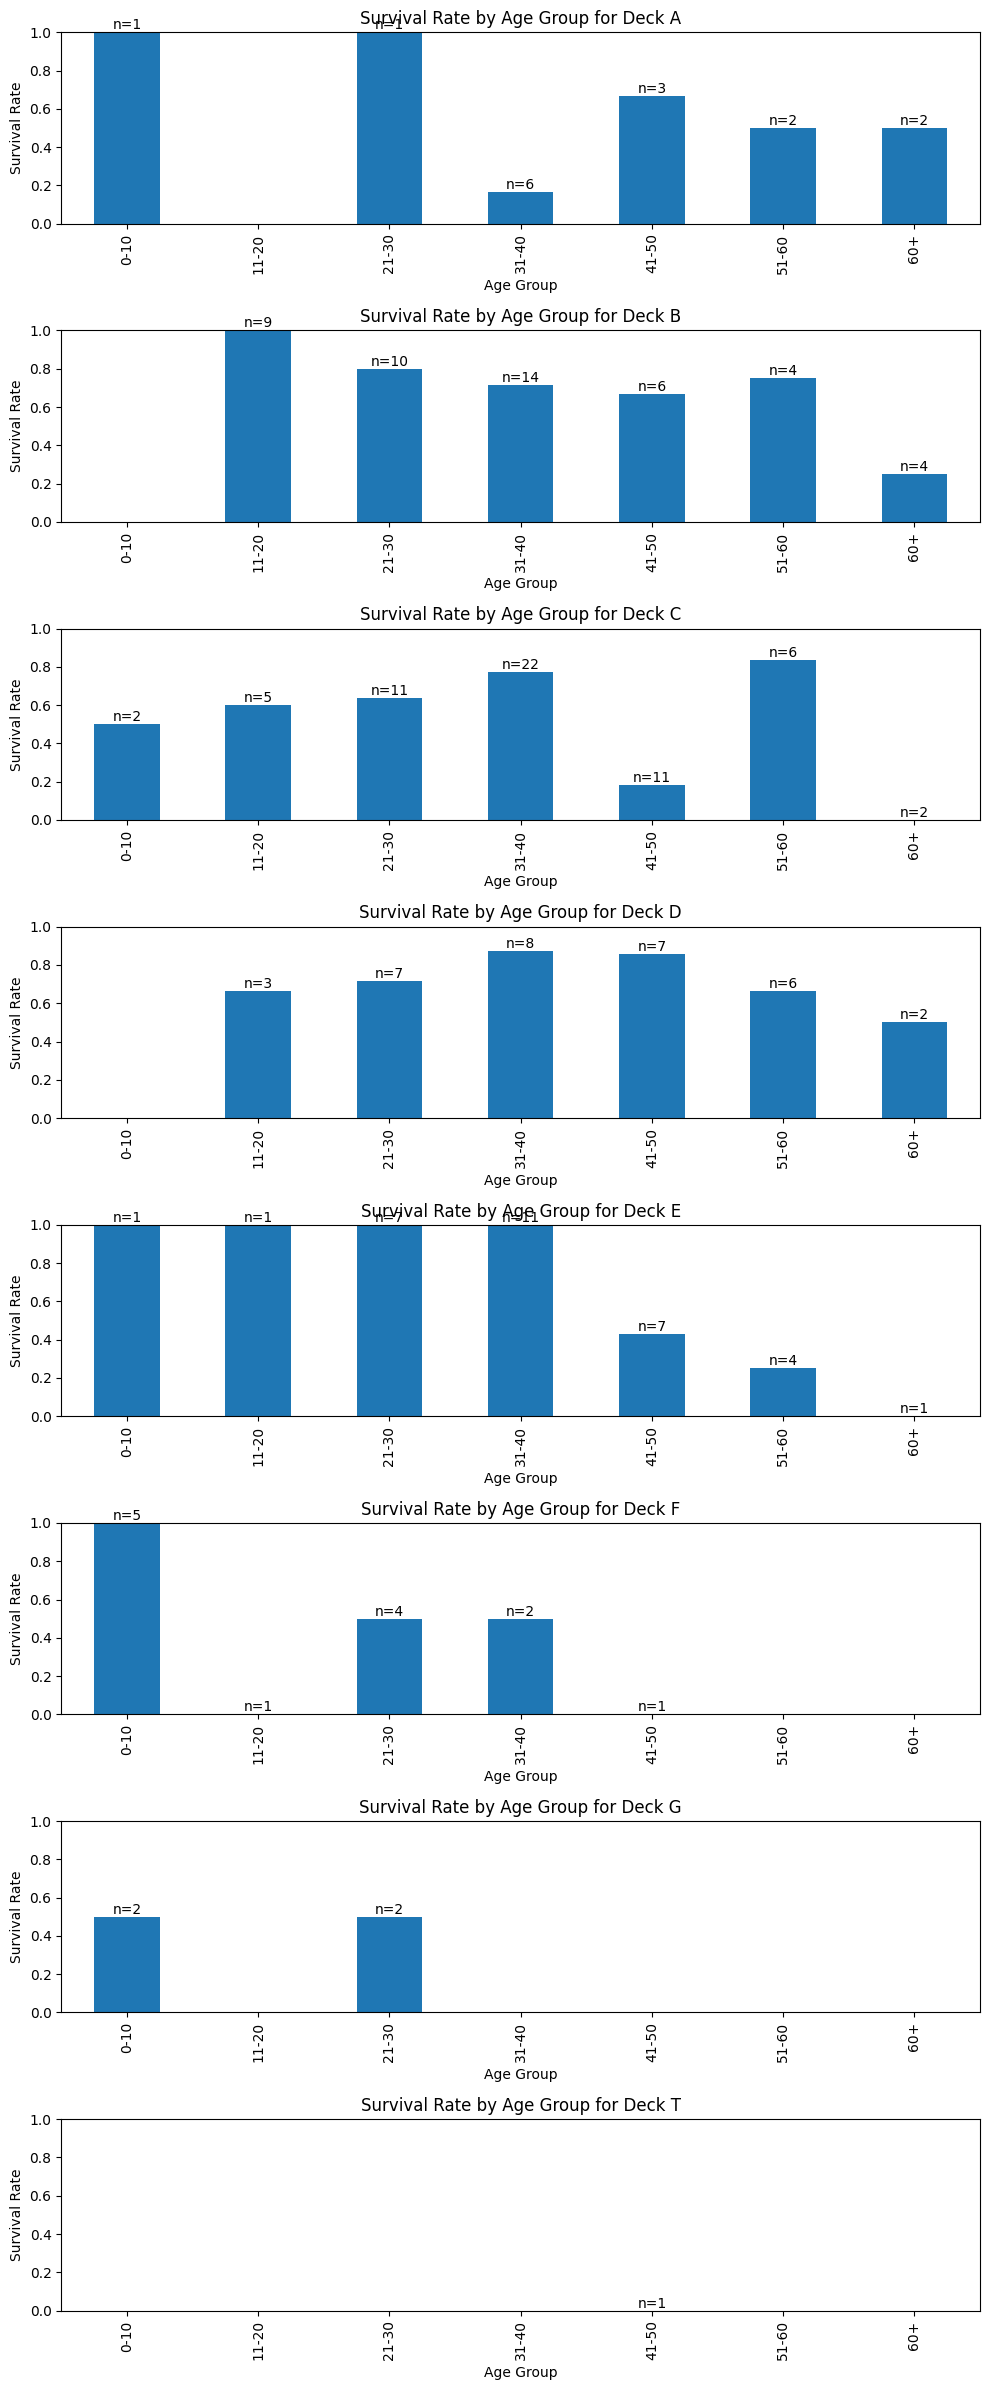

C:\Users\Shrijan Aryal\AppData\Local\Temp\ipykernel_15120\1767665822.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_survival = data.groupby(['Deck', 'Age_Group'])['Survived'].agg(['mean', 'count'])
C:\Users\Shrijan Aryal\AppData\Local\Temp\ipykernel_15120\1767665822.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_pivot = data.groupby(['Deck', 'Age_Group'])['Survived'].mean().unstack()


Survival Rates by Deck and Age Group:
                    mean  count
Deck Age_Group                 
A    0-10       1.000000      1
     11-20           NaN      0
     21-30      1.000000      1
     31-40      0.166667      6
     41-50      0.666667      3
     51-60      0.500000      2
     60+        0.500000      2
B    0-10            NaN      0
     11-20      1.000000      9
     21-30      0.800000     10
     31-40      0.714286     14
     41-50      0.666667      6
     51-60      0.750000      4
     60+        0.250000      4
C    0-10       0.500000      2
     11-20      0.600000      5
     21-30      0.636364     11
     31-40      0.772727     22
     41-50      0.181818     11
     51-60      0.833333      6
     60+        0.000000      2
D    0-10            NaN      0
     11-20      0.666667      3
     21-30      0.714286      7
     31-40      0.875000      8
     41-50      0.857143      7
     51-60      0.666667      6
     60+        0.500000      2
E 

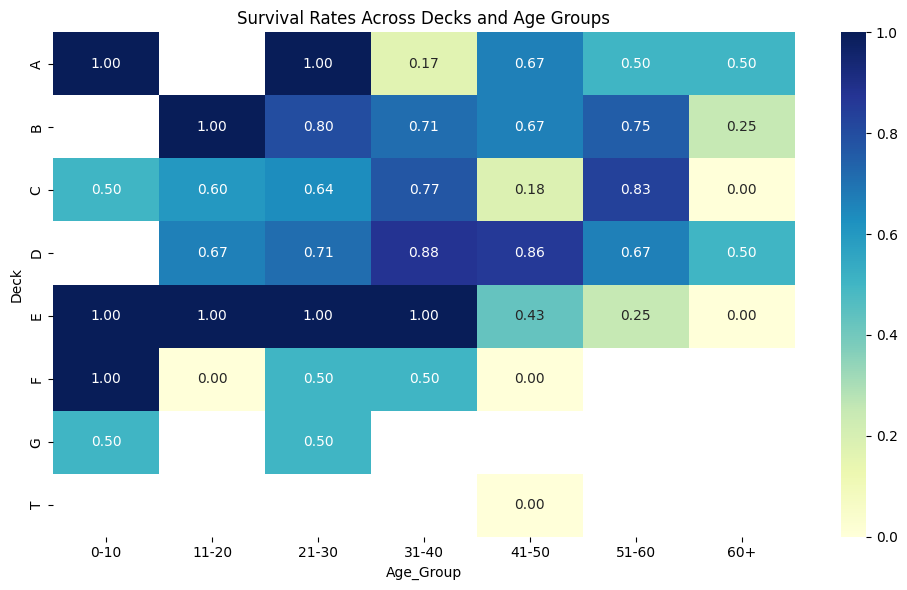

In [298]:
    import seaborn as sns

    # Create age bins for better grouping
    data['Age_Group'] = pd.cut(data['Age'], 
        bins=[0, 10, 20, 30, 40, 50, 60, 100], 
        labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+'])
    
    # Prepare the figure for subplots
    floors = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
    fig, axes = plt.subplots(len(floors), 1, figsize=(10, 3*len(floors)), squeeze=False)
    
    # Analyze each floor
    for i, floor in enumerate(floors):
        # Filter data for specific floor
        ship_floor = data[data['Deck'] == floor]
        
        # Group by age groups and calculate survival rate
        survival_by_age_group = ship_floor.groupby('Age_Group')['Survived'].agg(['mean', 'count'])
        
        # Plot bar chart
        ax = axes[i, 0]
        survival_by_age_group['mean'].plot(kind='bar', ax=ax, 
            title=f'Survival Rate by Age Group for Deck {floor}')
        
        # Annotate with count
        for j, v in enumerate(survival_by_age_group['mean']):
            count = survival_by_age_group['count'][j]
            ax.text(j, v, f'n={count}', ha='center', va='bottom')
        
        ax.set_xlabel('Age Group')
        ax.set_ylabel('Survival Rate')
        ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Overall survival rate by deck and age group
    overall_survival = data.groupby(['Deck', 'Age_Group'])['Survived'].agg(['mean', 'count'])
    print("Survival Rates by Deck and Age Group:")
    print(overall_survival)
    
    # Heatmap of survival rates
    survival_pivot = data.groupby(['Deck', 'Age_Group'])['Survived'].mean().unstack()
    plt.figure(figsize=(10, 6))
    sns.heatmap(survival_pivot, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Survival Rates Across Decks and Age Groups')
    plt.tight_layout()
    plt.show()


In [299]:
# Now, let's since that the missing age values are predicted using a randomForestRegressor model, we will procede towards finding 
# the best model to predict the missing values for the cabin column.
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly', 'Sex_male',
       'Pclass_Sex', 'Cabin_Code', 'Deck', 'Cabin_Number', 'Cabin_Position',
       'Age_Group'],
      dtype='object')

In [300]:
data.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Mrs,Title_Rare,IsElderly,Sex_male,Pclass_Sex,Cabin_Code,Deck,Cabin_Number,Cabin_Position,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,...,0,0,0,True,3,-1,NaN,NaN,NaN,21-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,1,0,0,False,0,81,C,85.0,back,31-40
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,...,0,0,0,False,0,-1,NaN,NaN,NaN,21-30
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,...,1,0,0,False,0,55,C,123.0,back,31-40
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,...,0,0,0,True,3,-1,NaN,NaN,NaN,31-40


In [301]:

col = ['Pclass','Family','Survived','Sex_male', 'IsElderly','Fare','Pclass_Sex','Age']
data_missing = data[data['Cabin'].isnull()][col]
data_complete = data[data['Cabin'].notnull()][col]

In [302]:
data['Deck'].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [303]:

deck_counts = data['Deck'].value_counts(dropna=False)
print(deck_counts)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64


In [304]:
data['Deck'] = data['Deck'].replace({'T': 'Other', 'F': 'Other', 'G': 'Other'})

# Mapping the remaining categories to numerical values
deck_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E':4, 'Other': 5}
data['Deck'] = data['Deck'].map(deck_mapping)

In [305]:
data['Deck'].head()

0    NaN
1    2.0
2    NaN
3    2.0
4    NaN
Name: Deck, dtype: float64

In [306]:
data.head(2)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Mrs,Title_Rare,IsElderly,Sex_male,Pclass_Sex,Cabin_Code,Deck,Cabin_Number,Cabin_Position,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,...,0,0,0,True,3,-1,NaN,NaN,NaN,21-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,1,0,0,False,0,81,2.0,85.0,back,31-40


In [83]:
# title_column = ['Sex_male']
# data[title_column] = data[title_column].astype(int)

In [307]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Assume data_complete is already defined and contains the necessary columns
# col contains feature column names, and 'Deck' is the target variable.
X_complete = data_complete[col]  # Features
y_complete = data[data['Deck'].notnull()]['Deck']  # Target variable

# Define models and their hyperparameter grids
models = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'solver': ['liblinear', 'lbfgs']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 3, 5, 7],
            'min_samples_split': [2, 5, 10]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree']
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    }
}

# List to collect the results
results = []

# Iterate through each model and perform grid search with 5-fold CV
for name, config in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(config['model'],
                        config['params'],
                        cv=5,
                        scoring='accuracy',  # Using accuracy for classification
                        n_jobs=-1)
    grid.fit(X_complete, y_complete)
    
    # Get the best accuracy score
    best_accuracy = grid.best_score_
    
    results.append({
        'Model': name,
        'Best_Accuracy': best_accuracy,
        'Best_Params': grid.best_params_
    })

# Convert results to a DataFrame and print
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)

Tuning LogisticRegression...
Tuning DecisionTree...
Tuning RandomForest...
Tuning GradientBoosting...
Tuning KNN...
Tuning SVM...

Hyperparameter Tuning Results:
                Model  Best_Accuracy  \
0  LogisticRegression       0.367683   
1        DecisionTree       0.495000   
2        RandomForest       0.470366   
3    GradientBoosting       0.543902   
4                 KNN       0.421585   
5                 SVM       0.377317   

                                         Best_Params  
0                  {'C': 1.0, 'solver': 'liblinear'}  
1  {'criterion': 'gini', 'max_depth': None, 'min_...  
2  {'max_depth': None, 'min_samples_split': 2, 'n...  
3  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  
4  {'algorithm': 'auto', 'n_neighbors': 3, 'weigh...  
5         {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}  


In [308]:
# Filter for GradientBoosting results
best_gradient_boosting = results_df[results_df['Model'] == 'GradientBoosting']

# Display the best parameters for GradientBoosting
print("\nBest Parameters for GradientBoosting:")
print(best_gradient_boosting)



Best Parameters for GradientBoosting:
              Model  Best_Accuracy  \
3  GradientBoosting       0.543902   

                                         Best_Params  
3  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  


In [309]:
col = ['Pclass','Family','Survived','Sex_male','IsElderly','Fare','Pclass_Sex','Age']
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold


# Separate data with known and unknown ages from the original dataset
X_known = data_complete.loc[data['Deck'].notnull(), col]
y_known = data.loc[data['Deck'].notnull(), 'Deck']
X_unknown = data.loc[data['Deck'].isnull(), col]


# Define the RandomForestRegressor with grid search
gb_model = GradientBoostingClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'learning_rate':[0.1],
    'n_estimators': [50, 100, 200],
    'max_depth': [5]
}


# Perform GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=gb_model, 
    param_grid=param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # negative MSE for regression
    n_jobs=-1  # Use all available cores
)

# Fit the grid search
grid_search.fit(X_known, y_known)

# Best model details
print("Best Parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

# Best model
best_model = grid_search.best_estimator_


# Perform 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_rf_model, 
    X_known, 
    y_known, 
    cv=cv, 
    scoring='accuracy'
)

# Convert to RMSE
cv_rmse_scores = np.sqrt(-cv_scores)

# Print cross-validation results
print("\nCross-Validation Results:")
print("Accuracy scores:", cv_scores)
print("Mean Accuracy: {:.4f} (+/- {:.4f})".format(
    cv_scores.mean(), 
    cv_scores.std() * 2
))

# Predict missing cabins
predicted_cabins = best_model.predict(X_unknown)

# Create a copy of the original dataframe
data_imputed = data.copy()

# Fill missing ages with predictions
data_imputed.loc[data_imputed['Deck'].isnull(), 'Deck'] = predicted_cabins

# Validation
print("\nMissing Cabin Values:")
print("Before imputation:", data['Deck'].isnull().sum())
print("After imputation:", data_imputed['Deck'].isnull().sum())

data['Deck'] = data_imputed['Deck']

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best accuracy: 0.5439024390243903


C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 350, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shrijan 


Cross-Validation Results:
Accuracy scores: [nan nan nan nan nan]
Mean Accuracy: nan (+/- nan)

Missing Cabin Values:
Before imputation: 687
After imputation: 0


C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 350, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shrijan Aryal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shrijan 

In [310]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'IsElderly', 'Sex_male',
       'Pclass_Sex', 'Cabin_Code', 'Deck', 'Cabin_Number', 'Cabin_Position',
       'Age_Group'],
      dtype='object')

In [311]:
X = ['Pclass',  'Sex_male', 'Age', 'Family', 'Fare', 'Embarked', 'Deck','Pclass_Sex','IsElderly']

y = ['Survived']
data['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [317]:
X = ['Sex_male', 'Age', 'Family', 'Fare', 'Deck','Pclass_Sex','IsElderly']

y = ['Survived']

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Assume data_complete is already defined and contains the necessary columns
X_data = data[X]  # Features
y_data = data[y].values.ravel()  # Target variable


# Define models and their hyperparameter grids
models = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'solver': ['liblinear', 'lbfgs']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 3, 5, 7],
            'min_samples_split': [2, 5, 10]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree']
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    }
}

# List to collect the results
results = []

# Iterate through each model and perform grid search with 5-fold CV
for name, config in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(config['model'],
                        config['params'],
                        cv=5,
                        scoring='accuracy',  # Using accuracy for classification
                        n_jobs=-1)
    grid.fit(X_data, y_data)
    
    # Get the best accuracy score
    best_accuracy = grid.best_score_
    
    results.append({
        'Model': name,
        'Best_Accuracy': best_accuracy,
        'Best_Params': grid.best_params_
    })

# Convert results to a DataFrame and print
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)

Tuning LogisticRegression...
Tuning DecisionTree...
Tuning RandomForest...
Tuning GradientBoosting...
Tuning KNN...
Tuning SVM...

Hyperparameter Tuning Results:
                Model  Best_Accuracy  \
0  LogisticRegression       0.784521   
1        DecisionTree       0.831649   
2        RandomForest       0.846249   
3    GradientBoosting       0.845113   
4                 KNN       0.739671   
5                 SVM       0.786737   

                                         Best_Params  
0                  {'C': 1.0, 'solver': 'liblinear'}  
1  {'criterion': 'gini', 'max_depth': 5, 'min_sam...  
2  {'max_depth': None, 'min_samples_split': 10, '...  
3  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...  
4  {'algorithm': 'auto', 'n_neighbors': 9, 'weigh...  
5   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  


In [318]:
best_model = grid.best_estimator_
best_params = grid.best_params_
print(best_params)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [319]:
import pickle

In [320]:
# Save the model
with open('best_model4.pkl', 'wb') as f:
    pickle.dump(best_model, f)